In [1]:
pip install pymc arviz

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pymc as pm
import arviz as az

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
stocks = [
    "TCS",
    "Infosys",
    "Reliance",
    "HDFC",
    "ITC"
]

# Bayesian Inference Loop

In [4]:
posterior_results = []


Processing TCS


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/.local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 135 seconds.


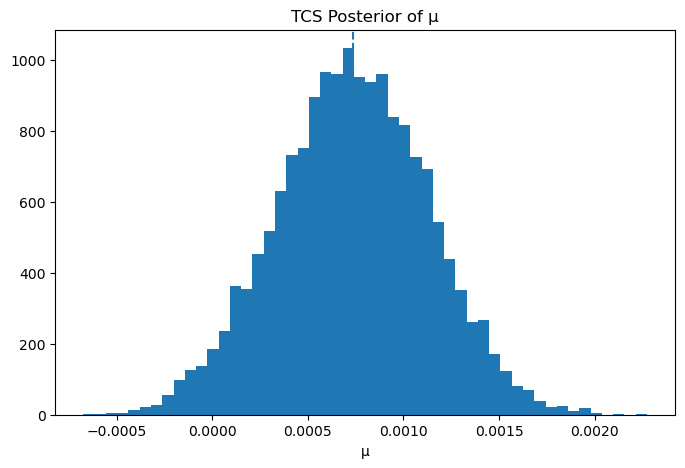

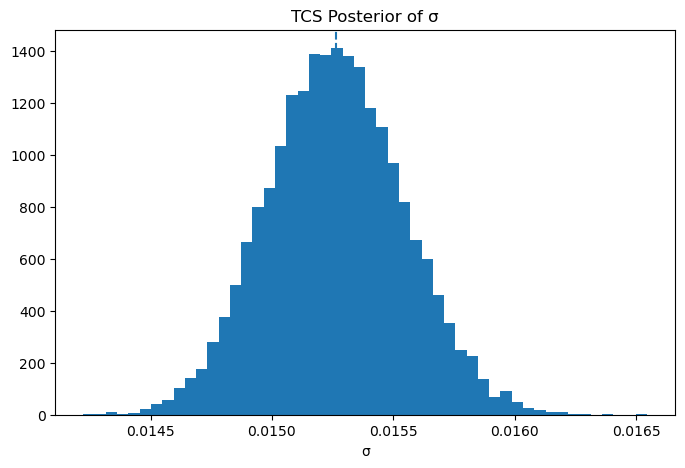

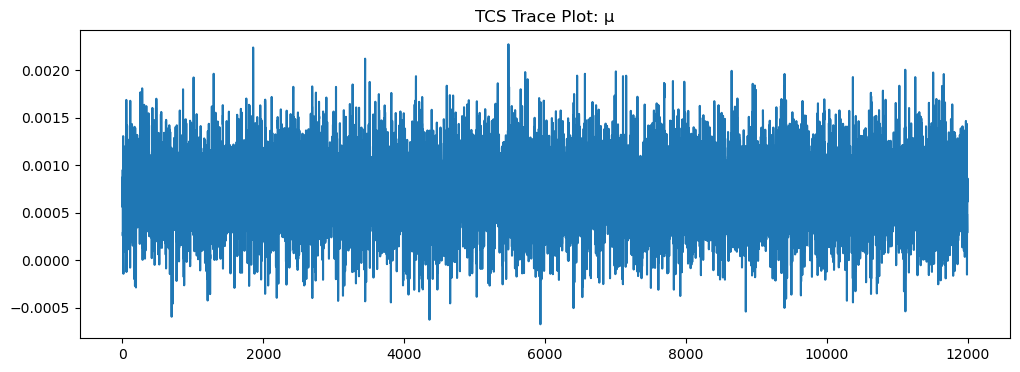

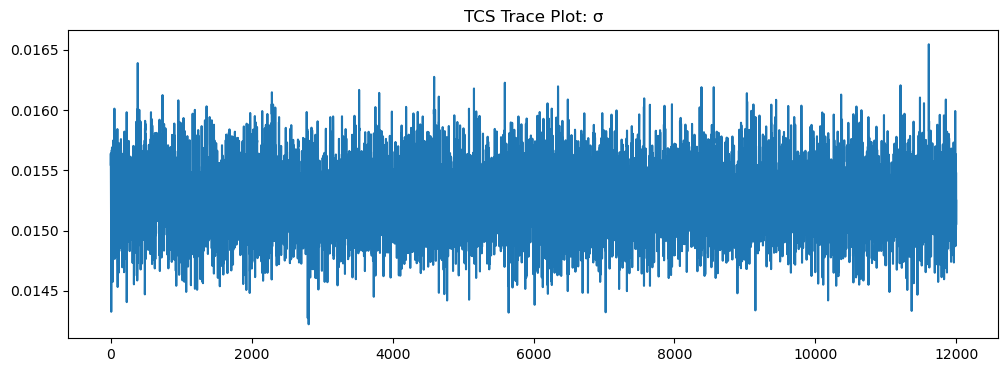


Processing Infosys


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/.local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 159 seconds.


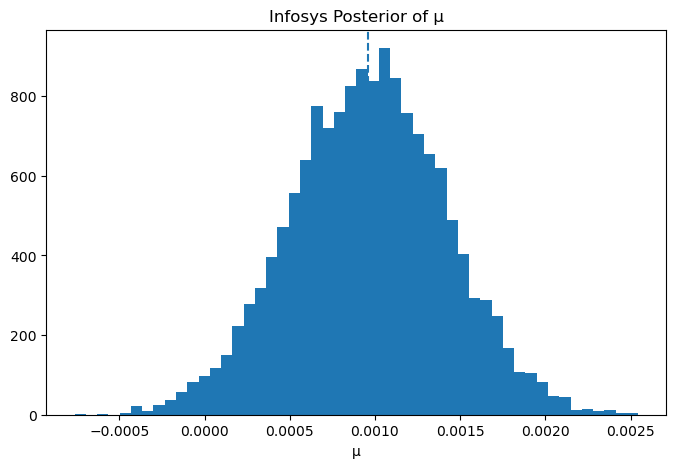

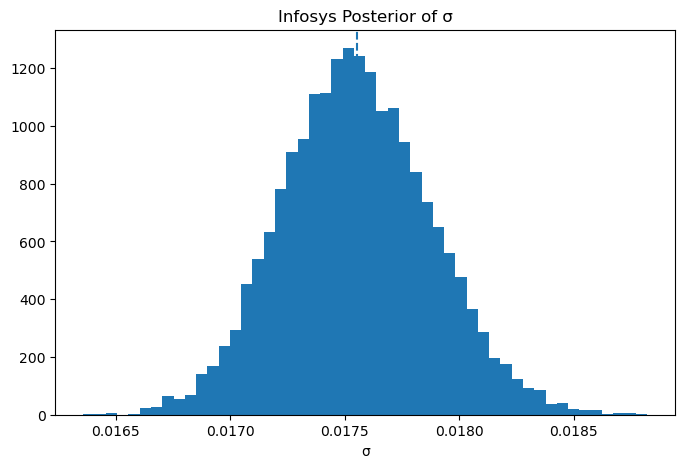

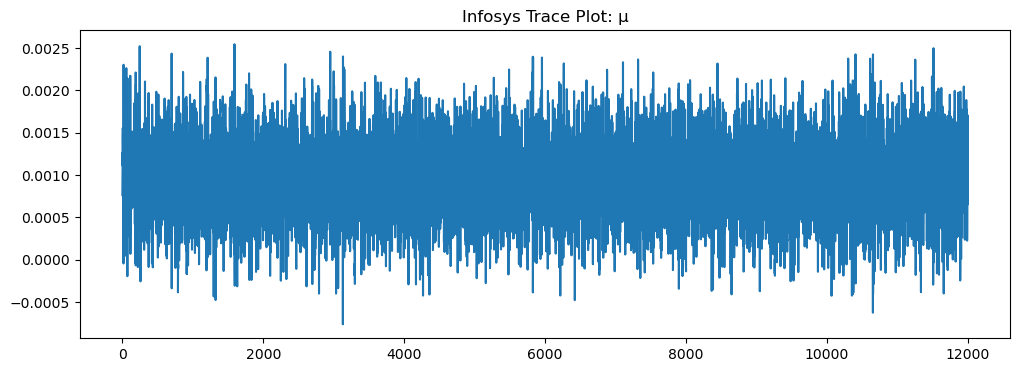

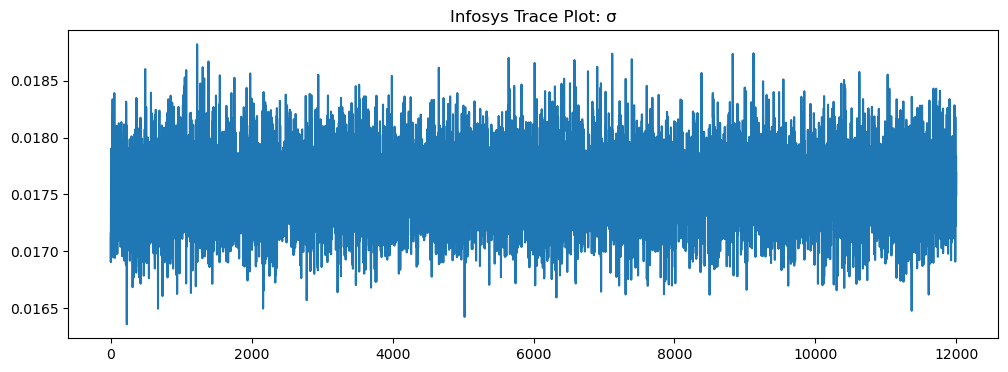


Processing Reliance


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/.local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 178 seconds.


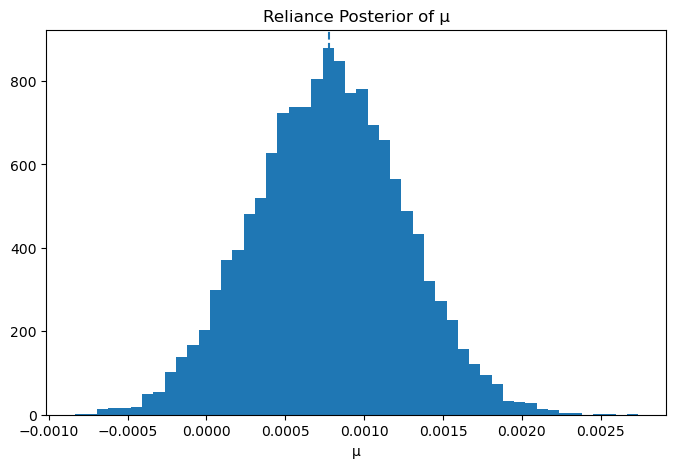

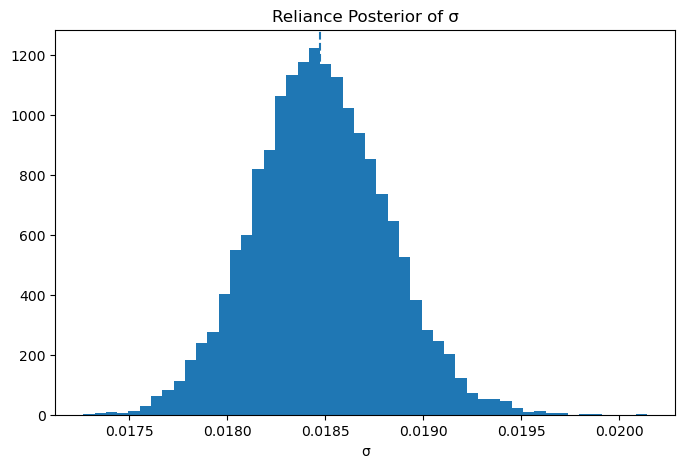

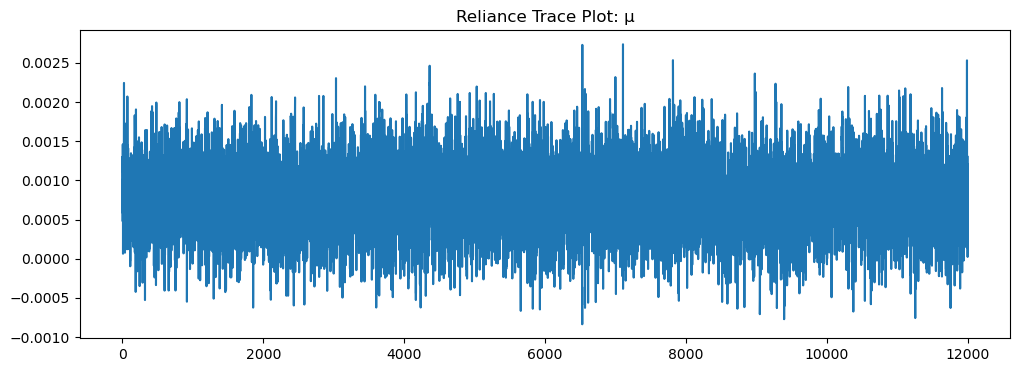

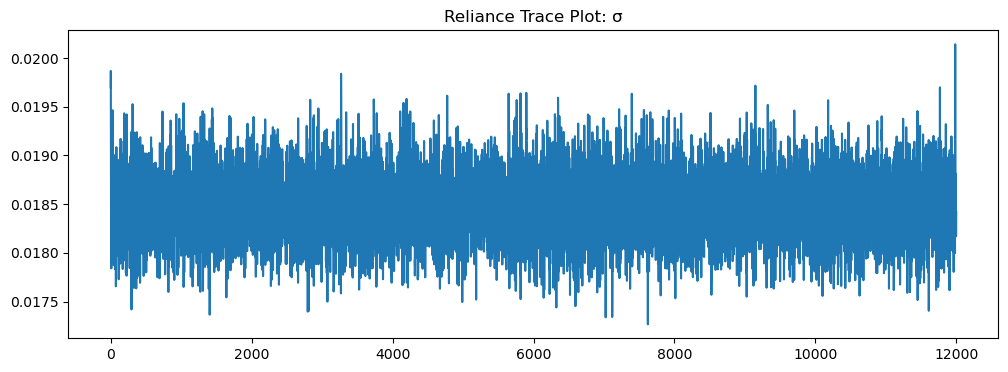


Processing HDFC


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/.local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 149 seconds.


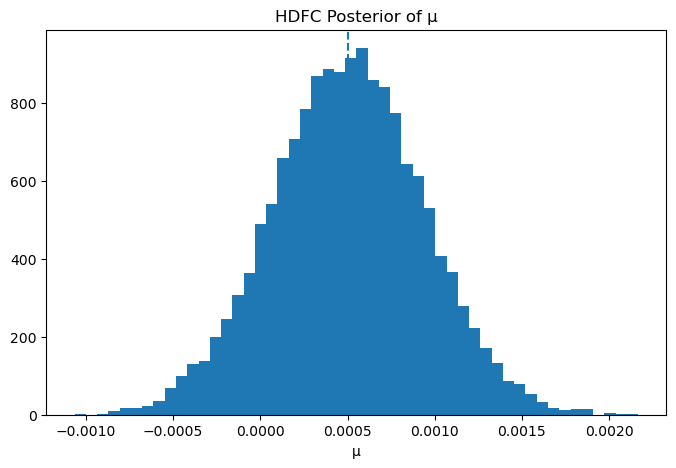

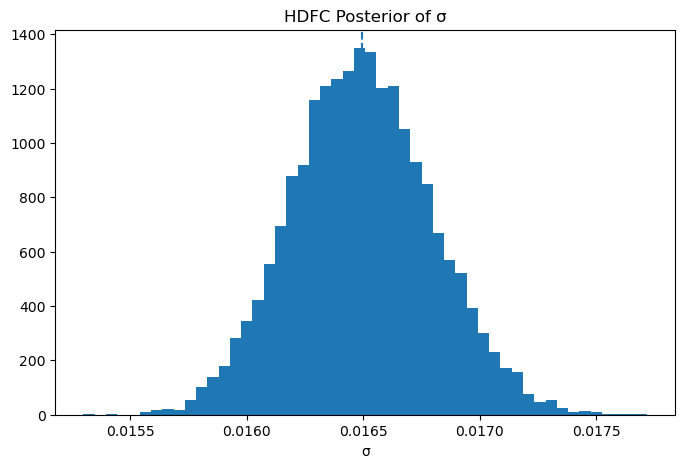

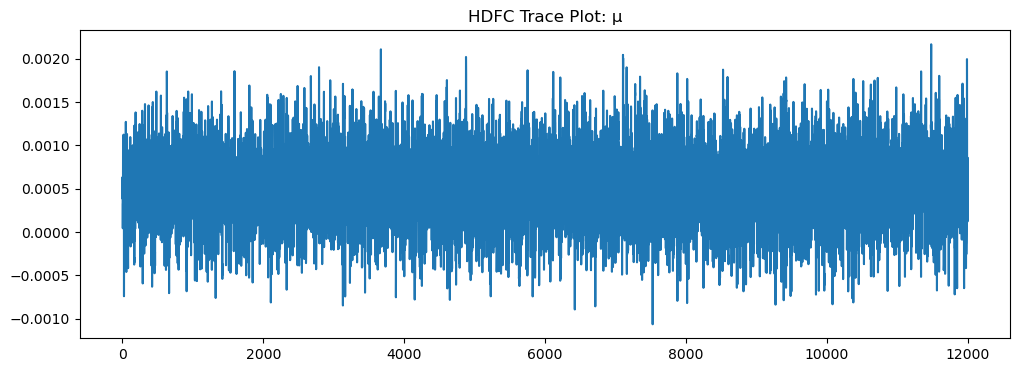

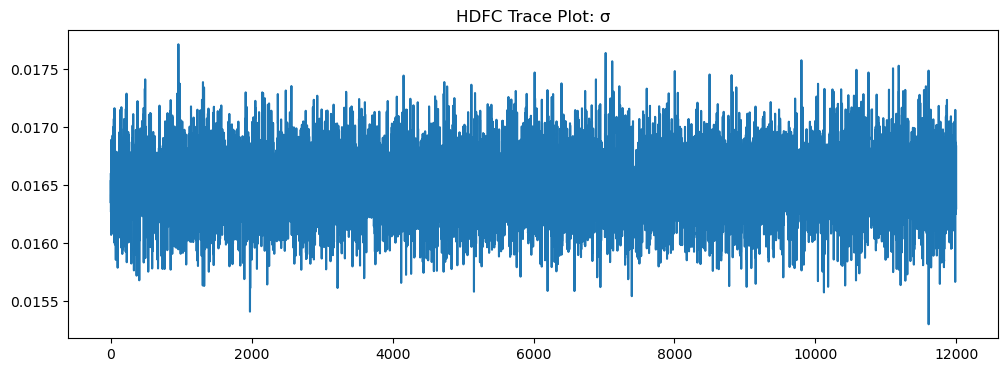


Processing ITC


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/.local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 139 seconds.


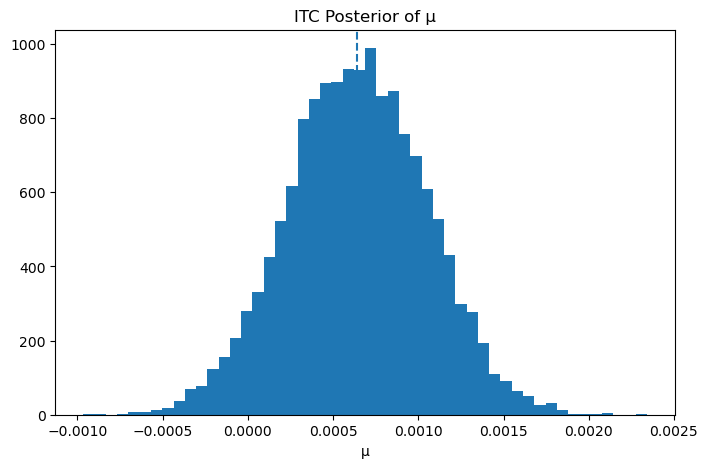

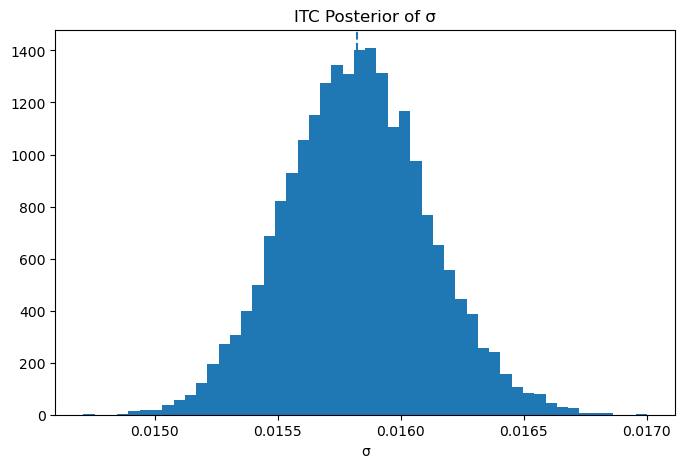

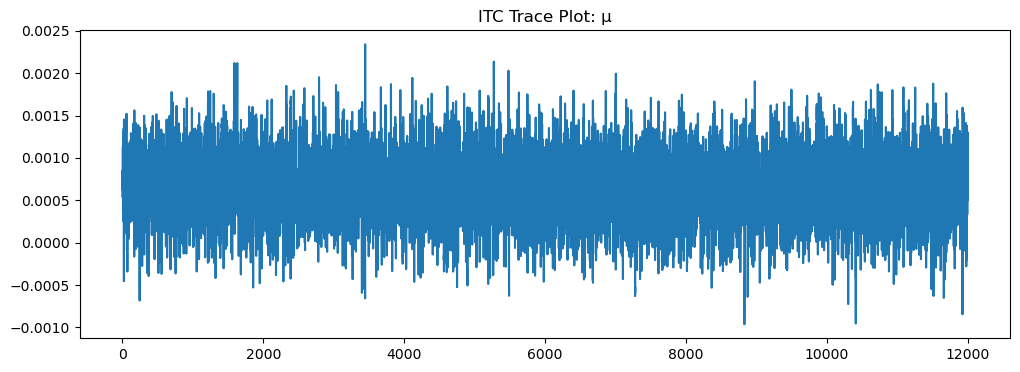

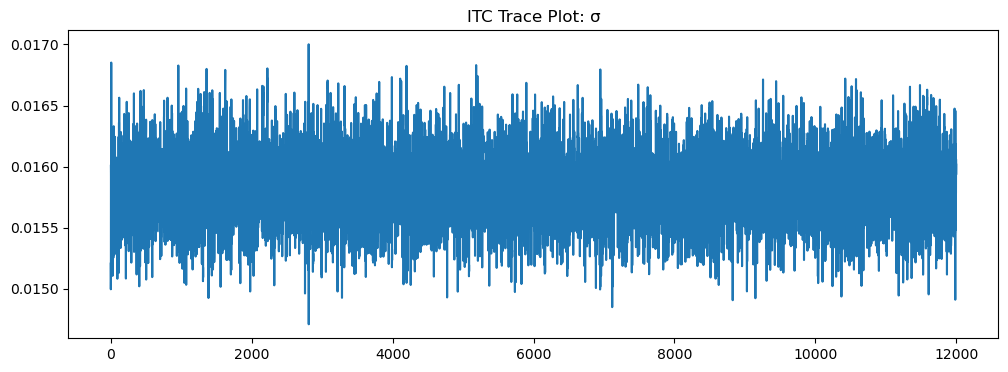

In [5]:


for stock in stocks:

    print(f"\n{'='*50}")
    print(f"Processing {stock}")
    print(f"{'='*50}")

    # Load Data
    df = pd.read_csv(
        f"Data_with_returns/{stock}_returns.csv"
    )

    returns = df["Return"].dropna().values

    # Bayesian Model
    with pm.Model() as model:

        # Prior for Mean Return
        mu = pm.Normal(
            "mu",
            mu=0,
            sigma=0.02
        )

        # Prior for Volatility
        sigma = pm.HalfNormal(
            "sigma",
            sigma=0.02
        )

        # Likelihood
        obs = pm.Normal(
            "obs",
            mu=mu,
            sigma=sigma,
            observed=returns
        )

        # NUTS Sampling
        trace = pm.sample(
            draws=3000,
            tune=1500,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=42,
            return_inferencedata=True
        )

    # Extract Posterior Samples
    mu_samples = (
        trace.posterior["mu"]
        .values
        .flatten()
    )

    sigma_samples = (
        trace.posterior["sigma"]
        .values
        .flatten()
    )

    # Posterior Means
    mu_mean = np.mean(mu_samples)

    sigma_mean = np.mean(
        sigma_samples
    )

    # 95% Credible Intervals
    mu_ci = np.percentile(
        mu_samples,
        [2.5, 97.5]
    )

    sigma_ci = np.percentile(
        sigma_samples,
        [2.5, 97.5]
    )

    posterior_results.append({

        "Stock": stock,

        "Posterior_Mean_mu":
            mu_mean,

        "Posterior_Mean_sigma":
            sigma_mean,

        "Mu_CI_Lower":
            mu_ci[0],

        "Mu_CI_Upper":
            mu_ci[1],

        "Sigma_CI_Lower":
            sigma_ci[0],

        "Sigma_CI_Upper":
            sigma_ci[1]

    })

# μ Posterior
    plt.figure(figsize=(8,5))

    plt.hist(
        mu_samples,
        bins=50,
        density=True
    )

    plt.axvline(
        mu_mean,
        linestyle="--"
    )

    plt.title(
        f"{stock} Posterior of μ"
    )

    plt.xlabel("μ")

    plt.savefig(
        f"{stock}_posterior_mu.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# σ Posterior
    plt.figure(figsize=(8,5))

    plt.hist(
        sigma_samples,
        bins=50,
        density=True
    )

    plt.axvline(
        sigma_mean,
        linestyle="--"
    )

    plt.title(
        f"{stock} Posterior of σ"
    )

    plt.xlabel("σ")

    plt.savefig(
        f"{stock}_posterior_sigma.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# Trace Plot for μ and σ    
    plt.figure(figsize=(12,4))

    plt.plot(
        mu_samples
    )

    plt.title(
        f"{stock} Trace Plot: μ"
    )

    plt.savefig(
        f"{stock}_trace_mu.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.figure(figsize=(12,4))

    plt.plot(
        sigma_samples
    )

    plt.title(
        f"{stock} Trace Plot: σ"
    )

    plt.savefig(
        f"{stock}_trace_sigma.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    
    


In [6]:
# Final Results DataFrame
posterior_df = pd.DataFrame(
    posterior_results
)

print("\nPosterior Summary:")
print(posterior_df)

posterior_df.to_csv(
    "posterior_results.csv",
    index=False
)


Posterior Summary:
      Stock  Posterior_Mean_mu  Posterior_Mean_sigma  Mu_CI_Lower  \
0       TCS           0.000735              0.015262    -0.000052   
1   Infosys           0.000961              0.017551     0.000054   
2  Reliance           0.000774              0.018475    -0.000147   
3      HDFC           0.000503              0.016496    -0.000364   
4       ITC           0.000643              0.015822    -0.000162   

   Mu_CI_Upper  Sigma_CI_Lower  Sigma_CI_Upper  
0     0.001499        0.014729        0.015823  
1     0.001857        0.016929        0.018212  
2     0.001697        0.017823        0.019156  
3     0.001357        0.015921        0.017106  
4     0.001428        0.015262        0.016406  
